In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

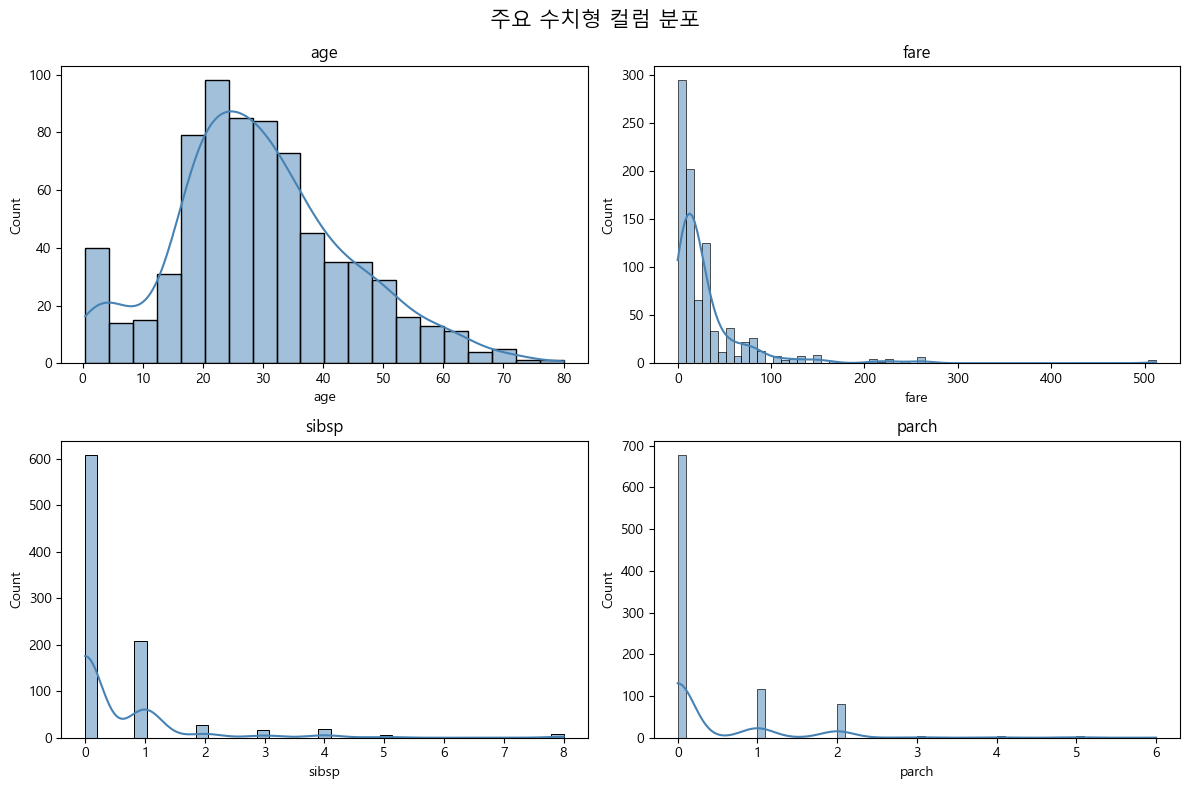

=== IQR 이상치 탐지 결과 ===

[age]
  정상 범위: 2.50 ~ 54.50
  이상치 개수: 66개 (7.4%)

[fare]
  정상 범위: -26.72 ~ 65.63
  이상치 개수: 116개 (13.0%)

[sibsp]
  정상 범위: -1.50 ~ 2.50
  이상치 개수: 46개 (5.2%)

[parch]
  정상 범위: 0.00 ~ 0.00
  이상치 개수: 213개 (23.9%)



In [7]:

# 1. **IQR 방법 (Interquartile Range)**
#    - 1사분위수 (Q1), 3사분위수 (Q3) 계산
#    - IQR = Q3 - Q1
#    - 이상치 범위: Q1 - 1.5×IQR ~ Q3 + 1.5×IQR
#    - 범위 밖의 값을 이상치로 분류

plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


df = sns.load_dataset('titanic')

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({
    '결측 수': missing,
    '결측률(%)': missing_pct
}).query('`결측 수` > 0')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('주요 수치형 컬럼 분포', fontsize=15)

cols = ['age', 'fare', 'sibsp', 'parch']

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(col)

plt.tight_layout()
plt.show()

df['age'] = df['age'].fillna(df['age'].median())
df['age'].isnull().sum()

numeric_cols = ['age', 'fare', 'sibsp', 'parch']

print('=== IQR 이상치 탐지 결과 ===\n')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f'[{col}]')
    print(f'  정상 범위: {lower_bound:.2f} ~ {upper_bound:.2f}')
    print(f'  이상치 개수: {len(outliers)}개 ({len(outliers)/len(df)*100:.1f}%)\n')

In [8]:
# 2. **Z-score 방법**
#    - Z-score = (x - mean) / std
#    - |Z-score| > 3: 이상치 (극단적)
#    - |Z-score| > 2.5: 이상치 (의심)
#    - 표준정규분포 가정

# 1. 타이타닉 데이터 로드
df = sns.load_dataset('titanic')

# 2. 분석할 컬럼 선택 (요금: Fare)
# 결측치가 있을 수 있으므로 처리 (Z-score는 평균 기반이라 결측치에 민감함)
target_col = 'fare'
df = df.dropna(subset=[target_col])

# 3. Z-score 계산
mean_fare = df[target_col].mean()
std_fare = df[target_col].std()

df['z_score'] = (df[target_col] - mean_fare) / std_fare

# 4. 임계값(Threshold) 기준 설정 및 추출
# |Z| > 3: 극단적 이상치
extreme_outliers = df[df['z_score'].abs() > 3]

# |Z| > 2.5: 의심되는 이상치
suspected_outliers = df[(df['z_score'].abs() > 2.5) & (df['z_score'].abs() <= 3)]

# 5. 결과 확인
print(f"전체 승객 수: {len(df)}")
print(f"극단적 이상치 개수 (|Z| > 3): {len(extreme_outliers)}")
print(f"의심되는 이상치 개수 (2.5 < |Z| <= 3): {len(suspected_outliers)}")

# 상위 5개 이상치 데이터 보기
print("\n--- 극단적 이상치 샘플 (고액 납부자 등) ---")
print(extreme_outliers[[target_col, 'z_score', 'pclass', 'survived']].head())

전체 승객 수: 891
극단적 이상치 개수 (|Z| > 3): 20
의심되는 이상치 개수 (2.5 < |Z| <= 3): 2

--- 극단적 이상치 샘플 (고액 납부자 등) ---
         fare   z_score  pclass  survived
27   263.0000  4.644393       1         0
88   263.0000  4.644393       1         1
118  247.5208  4.332899       1         0
258  512.3292  9.661740       1         1
299  247.5208  4.332899       1         1


In [9]:
# 3. **이상치 처리**
#    - 삭제
#    - 경계값으로 대체 (Capping)
#    - 중앙값으로 대체
import pandas as pd
import seaborn as sns

# 데이터 로드 및 결측치 제거
df = sns.load_dataset('titanic')
df = df.dropna(subset=['fare']).reset_index(drop=True)

# Z-score 계산
mean_f, std_f = df['fare'].mean(), df['fare'].std()
df['z_score'] = (df['fare'] - mean_f) / std_f

# 이상치 인덱스 추출 (|Z| > 3 기준)
outlier_idx = df[df['z_score'].abs() > 3].index
print(f"이상치 개수: {len(outlier_idx)}")

# Z=3인 지점의 실제 요금 값 계산
upper_limit = mean_f + 3 * std_f
lower_limit = mean_f - 3 * std_f

df_capped = df.copy()
df_capped['fare'] = df_capped['fare'].clip(lower=lower_limit, upper=upper_limit)

print(f"수정 전 최대 요금: {df['fare'].max():.2f}")
print(f"수정 후 최대 요금: {df_capped['fare'].max():.2f}") # upper_limit으로 고정됨

median_fare = df['fare'].median()

df_median = df.copy()
df_median.loc[outlier_idx, 'fare'] = median_fare

print(f"이상치였던 샘플의 변경된 요금: {df_median.loc[outlier_idx[0], 'fare']}")


이상치 개수: 20
수정 전 최대 요금: 512.33
수정 후 최대 요금: 181.28
이상치였던 샘플의 변경된 요금: 14.4542


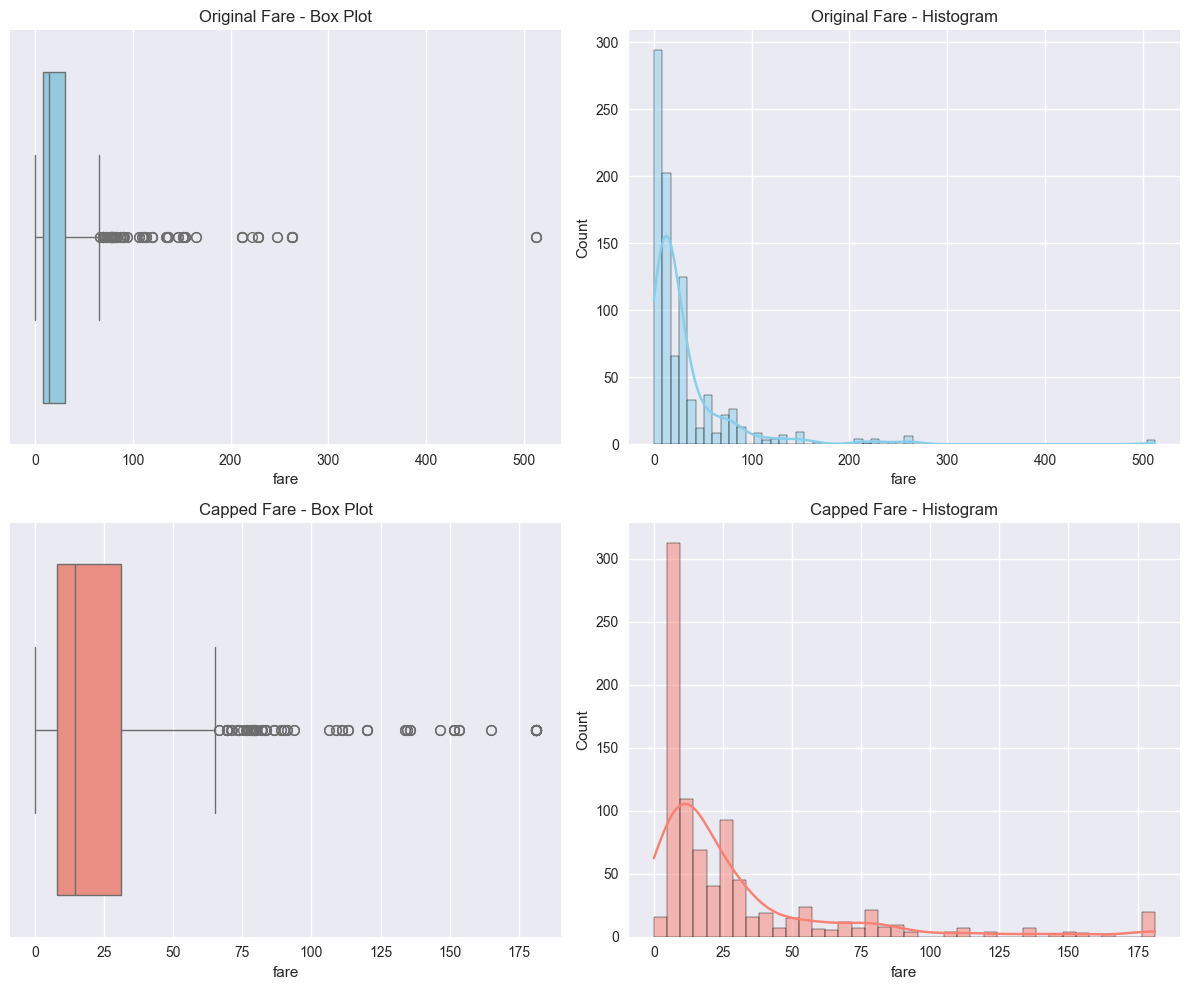

In [10]:

# 4. **시각화**
#    - Box plot으로 이상치 시각화
#    - 히스토그램으로 분포 확인

# 시각화 설정 (한글 깨짐 방지는 환경에 따라 설정 필요)
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 원본 데이터 (Original)
sns.boxplot(x=df['fare'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Original Fare - Box Plot')

sns.histplot(df['fare'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Original Fare - Histogram')

# 2. Capping 처리 후 데이터 (Capped)
sns.boxplot(x=df_capped['fare'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Capped Fare - Box Plot')

sns.histplot(df_capped['fare'], kde=True, ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Capped Fare - Histogram')

plt.tight_layout()
plt.show()